# Feature Importance Analysis

This notebook compares the importance of the features used by the different
classification models.

Four models provide native feature-importance measures:

- Random Forest
- AdaBoost
- XGBoost
- LightGBM

Because these algorithms calculate feature importance differently, their raw
importance values should not be compared directly. Therefore, the importance
values are normalized within each model and the feature rankings are compared
across models.

ANN and k-NN do not provide native feature importance. A common permutation
importance analysis can later be used to study feature relevance for all six
models using the 2023 validation set.

The 2024–2025 final test set is not used in this notebook.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

import sys
import joblib

from sklearn.metrics import roc_auc_score

import tensorflow as tf

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(
        str(PROJECT_ROOT)
    )

from src.preprocessing import (
    transform_data,
    numeric_features,
    categorical_features
)

In [ ]:
#Paths
RESULTS_DIR = Path("../results")

FEATURE_IMPORTANCE_DIR = (
    RESULTS_DIR
    / "feature_importance"
)

print(
    "Feature importance folder:",
    FEATURE_IMPORTANCE_DIR.resolve()
)

Feature importance folder: C:\Users\User\Documents\GitHub\artificial_intelligence\results\feature_importance


In [5]:
#Load the four saved files
rf_importance = pd.read_csv(
    FEATURE_IMPORTANCE_DIR
    / "rf_feature_importance.csv"
)

adaboost_importance = pd.read_csv(
    FEATURE_IMPORTANCE_DIR
    / "adaboost_feature_importance.csv"
)

xgboost_importance = pd.read_csv(
    FEATURE_IMPORTANCE_DIR
    / "xgboost_feature_importance.csv"
)

lightgbm_importance = pd.read_csv(
    FEATURE_IMPORTANCE_DIR
    / "lightgbm_feature_importance.csv"
)

print(
    "Random Forest:",
    rf_importance.shape
)

print(
    "AdaBoost:",
    adaboost_importance.shape
)

print(
    "XGBoost:",
    xgboost_importance.shape
)

print(
    "LightGBM:",
    lightgbm_importance.shape
)

Random Forest: (50, 2)
AdaBoost: (50, 2)
XGBoost: (50, 2)
LightGBM: (50, 2)


In [6]:
#Inspect one
rf_importance.head(10)

,Feature,Importance
0,PointsDifference,0.125788
1,RankDifference,0.097723
2,WinRateDifference,0.081795
3,SurfaceWinRateDifference,0.063267
4,Player2Points,0.047606
5,Player1Points,0.046803
6,Player1Rank,0.043834
7,Player2Rank,0.041618
8,SurfaceMatchesDifference,0.038916
9,ExperienceDifference,0.036477


In [7]:
#Verify that all four contain the same features
rf_features = set(
    rf_importance["Feature"]
)

adaboost_features = set(
    adaboost_importance["Feature"]
)

xgboost_features = set(
    xgboost_importance["Feature"]
)

lightgbm_features = set(
    lightgbm_importance["Feature"]
)


assert (
    rf_features
    ==
    adaboost_features
    ==
    xgboost_features
    ==
    lightgbm_features
)


print(
    "All models use the same",
    len(rf_features),
    "features."
)

All models use the same 50 features.


## Native Importance Normalization

The raw feature-importance values cannot be directly compared across models.

For example, Random Forest, AdaBoost, XGBoost and LightGBM use different
definitions of importance. LightGBM may report split counts, while other
models can use impurity reduction or gain-based measures.

For each model, the importances are therefore normalized so that they sum to 1. This makes it easier to examine the relative importance of features within
each model.

Cross-model conclusions will also consider feature rankings rather than only
the normalized values.

In [8]:
#Normalize each model
def normalize_importance(
    importance_data
):
    
    normalized_data = (
        importance_data.copy()
    )
    
    normalized_data[
        "NormalizedImportance"
    ] = (
        normalized_data[
            "Importance"
        ]
        /
        normalized_data[
            "Importance"
        ].sum()
    )
    
    return normalized_data

rf_importance = normalize_importance(
    rf_importance
)

adaboost_importance = normalize_importance(
    adaboost_importance
)

xgboost_importance = normalize_importance(
    xgboost_importance
)

lightgbm_importance = normalize_importance(
    lightgbm_importance
)

print(
    rf_importance[
        "NormalizedImportance"
    ].sum()
)

print(
    adaboost_importance[
        "NormalizedImportance"
    ].sum()
)

print(
    xgboost_importance[
        "NormalizedImportance"
    ].sum()
)

print(
    lightgbm_importance[
        "NormalizedImportance"
    ].sum()
)

1.0
0.9999999999999999
1.0
1.0


In [9]:
#Add model-specific names
rf_comparison = (
    rf_importance[
        [
            "Feature",
            "NormalizedImportance"
        ]
    ]
    .rename(
        columns={
            "NormalizedImportance":
                "RFImportance"
        }
    )
)


adaboost_comparison = (
    adaboost_importance[
        [
            "Feature",
            "NormalizedImportance"
        ]
    ]
    .rename(
        columns={
            "NormalizedImportance":
                "AdaBoostImportance"
        }
    )
)


xgboost_comparison = (
    xgboost_importance[
        [
            "Feature",
            "NormalizedImportance"
        ]
    ]
    .rename(
        columns={
            "NormalizedImportance":
                "XGBoostImportance"
        }
    )
)


lightgbm_comparison = (
    lightgbm_importance[
        [
            "Feature",
            "NormalizedImportance"
        ]
    ]
    .rename(
        columns={
            "NormalizedImportance":
                "LightGBMImportance"
        }
    )
)

In [12]:
#Merge everything
feature_comparison = (
    rf_comparison
    .merge(
        adaboost_comparison,
        on="Feature"
    )
    .merge(
        xgboost_comparison,
        on="Feature"
    )
    .merge(
        lightgbm_comparison,
        on="Feature"
    )
)


feature_comparison.head()

,Feature,RFImportance,AdaBoostImportance,XGBoostImportance,LightGBMImportance
0,PointsDifference,0.125788,0.518056,0.261584,0.121667
1,RankDifference,0.097723,0.037455,0.072032,0.058333
2,WinRateDifference,0.081795,0.088530,0.143982,0.036667
3,SurfaceWinRateDifference,0.063267,0.084506,0.093345,0.061667
4,Player2Points,0.047606,0.013468,0.027179,0.034167


In [13]:
feature_comparison.shape

(50, 5)

In [14]:
#Show each model's top 10
models = {
    "Random Forest":
        "RFImportance",

    "AdaBoost":
        "AdaBoostImportance",

    "XGBoost":
        "XGBoostImportance",

    "LightGBM":
        "LightGBMImportance"
}


for (
    model_name,
    importance_column
) in models.items():
    
    print(
        "\n",
        "=" * 60
    )
    
    print(
        model_name
    )
    
    print(
        "=" * 60
    )
    
    display(
        feature_comparison[
            [
                "Feature",
                importance_column
            ]
        ]
        .sort_values(
            importance_column,
            ascending=False
        )
        .head(10)
    )


Random Forest


,Feature,RFImportance
0,PointsDifference,0.125788
1,RankDifference,0.097723
2,WinRateDifference,0.081795
3,SurfaceWinRateDifference,0.063267
4,Player2Points,0.047606
5,Player1Points,0.046803
6,Player1Rank,0.043834
7,Player2Rank,0.041618
8,SurfaceMatchesDifference,0.038916
9,ExperienceDifference,0.036477



AdaBoost


,Feature,AdaBoostImportance
0,PointsDifference,0.518056
2,WinRateDifference,0.088530
3,SurfaceWinRateDifference,0.084506
10,Player1WinRateBefore,0.048445
5,Player1Points,0.038037
1,RankDifference,0.037455
19,Recent5WinRateDifference,0.028922
14,Player2MatchesBefore,0.021236
11,Player2WinRateBefore,0.019297
15,Player2SurfaceMatchesBefore,0.017197



XGBoost


,Feature,XGBoostImportance
0,PointsDifference,0.261584
2,WinRateDifference,0.143982
3,SurfaceWinRateDifference,0.093345
1,RankDifference,0.072032
8,SurfaceMatchesDifference,0.056334
28,Series_Grand Slam,0.029853
6,Player1Rank,0.028366
4,Player2Points,0.027179
15,Player2SurfaceMatchesBefore,0.026937
17,Player1SurfaceMatchesBefore,0.025968



LightGBM


,Feature,LightGBMImportance
0,PointsDifference,0.121667
3,SurfaceWinRateDifference,0.061667
9,ExperienceDifference,0.059167
1,RankDifference,0.058333
15,Player2SurfaceMatchesBefore,0.057500
19,Recent5WinRateDifference,0.053333
17,Player1SurfaceMatchesBefore,0.050000
18,DaysSinceLastMatchDifference,0.045833
12,Player2SurfaceWinRateBefore,0.037500
14,Player2MatchesBefore,0.036667


In [15]:
#Add ranks for each model
feature_comparison["RFRank"] = (
    feature_comparison["RFImportance"]
    .rank(
        ascending=False,
        method="min"
    )
)

feature_comparison["AdaBoostRank"] = (
    feature_comparison["AdaBoostImportance"]
    .rank(
        ascending=False,
        method="min"
    )
)

feature_comparison["XGBoostRank"] = (
    feature_comparison["XGBoostImportance"]
    .rank(
        ascending=False,
        method="min"
    )
)

feature_comparison["LightGBMRank"] = (
    feature_comparison["LightGBMImportance"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [16]:
#Average rank across models
rank_columns = [
    "RFRank",
    "AdaBoostRank",
    "XGBoostRank",
    "LightGBMRank"
]


feature_comparison[
    "AverageRank"
] = (
    feature_comparison[
        rank_columns
    ]
    .mean(
        axis=1
    )
)

consensus_ranking = (
    feature_comparison
    .sort_values(
        "AverageRank",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


consensus_ranking[
    [
        "Feature",
        "AverageRank",
        "RFRank",
        "AdaBoostRank",
        "XGBoostRank",
        "LightGBMRank"
    ]
].head(15)

,Feature,AverageRank,RFRank,AdaBoostRank,XGBoostRank,LightGBMRank
0,PointsDifference,1.00,1.0,1.0,1.0,1.0
1,SurfaceWinRateDifference,3.00,4.0,3.0,3.0,2.0
2,RankDifference,4.00,2.0,6.0,4.0,4.0
3,WinRateDifference,4.25,3.0,2.0,2.0,10.0
4,Player2Points,9.50,5.0,11.0,8.0,14.0
5,Player2SurfaceMatchesBefore,10.00,16.0,10.0,9.0,5.0
6,Player1Points,10.25,6.0,5.0,17.0,13.0
7,Player1WinRateBefore,10.75,11.0,4.0,13.0,15.0
8,Recent5WinRateDifference,11.00,20.0,7.0,11.0,6.0
9,SurfaceMatchesDifference,11.25,9.0,21.0,5.0,10.0


In [17]:
#Add average normalized importance
importance_columns = [
    "RFImportance",
    "AdaBoostImportance",
    "XGBoostImportance",
    "LightGBMImportance"
]


feature_comparison[
    "AverageNormalizedImportance"
] = (
    feature_comparison[
        importance_columns
    ]
    .mean(
        axis=1
    )
)

feature_comparison[
    [
        "Feature",
        "AverageNormalizedImportance",
        "AverageRank"
    ]
].sort_values(
    "AverageRank"
).head(15)

,Feature,AverageNormalizedImportance,AverageRank
0,PointsDifference,0.256774,1.00
3,SurfaceWinRateDifference,0.075696,3.00
1,RankDifference,0.066386,4.00
2,WinRateDifference,0.087743,4.25
4,Player2Points,0.030605,9.50
15,Player2SurfaceMatchesBefore,0.031450,10.00
5,Player1Points,0.033572,10.25
10,Player1WinRateBefore,0.034585,10.75
19,Recent5WinRateDifference,0.031201,11.00
8,SurfaceMatchesDifference,0.033555,11.25


In [18]:
#Final consensus top 15
top_15_features = (
    feature_comparison
    .sort_values(
        "AverageRank"
    )
    .head(15)
    .reset_index(
        drop=True
    )
)


top_15_features[
    [
        "Feature",
        "AverageRank",
        "AverageNormalizedImportance"
    ]
]

,Feature,AverageRank,AverageNormalizedImportance
0,PointsDifference,1.00,0.256774
1,SurfaceWinRateDifference,3.00,0.075696
2,RankDifference,4.00,0.066386
3,WinRateDifference,4.25,0.087743
4,Player2Points,9.50,0.030605
5,Player2SurfaceMatchesBefore,10.00,0.031450
6,Player1Points,10.25,0.033572
7,Player1WinRateBefore,10.75,0.034585
8,Recent5WinRateDifference,11.00,0.031201
9,SurfaceMatchesDifference,11.25,0.033555


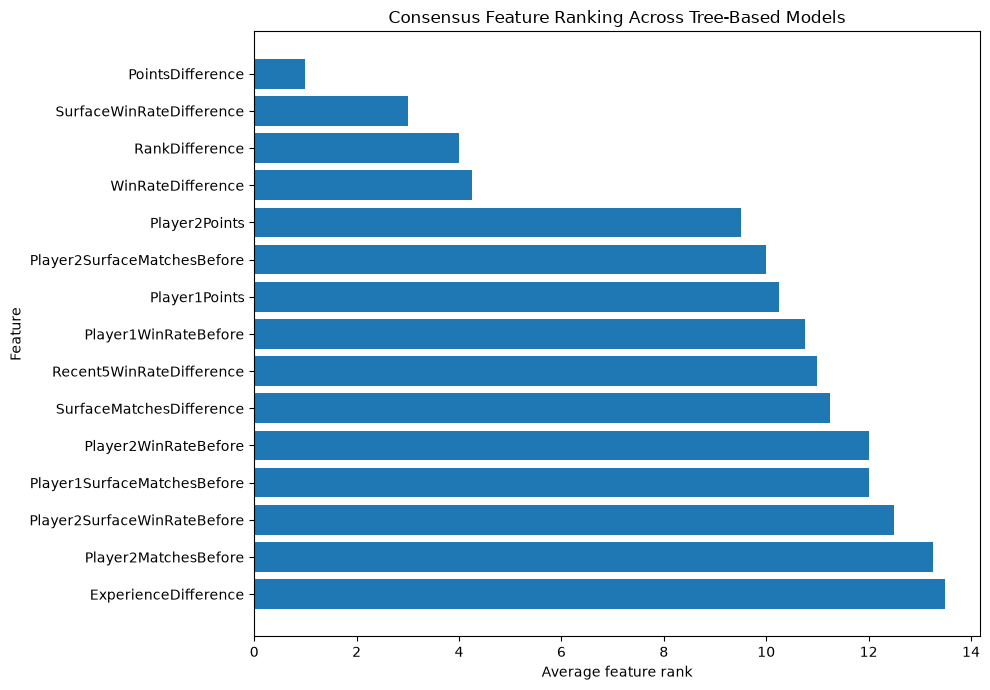

In [19]:
#Plot the consensus ranking
plot_data = (
    top_15_features
    .sort_values(
        "AverageRank",
        ascending=False
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    plot_data["Feature"],
    plot_data["AverageRank"]
)


plt.xlabel(
    "Average feature rank"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Consensus Feature Ranking Across Tree-Based Models"
)


plt.tight_layout()

plt.show()

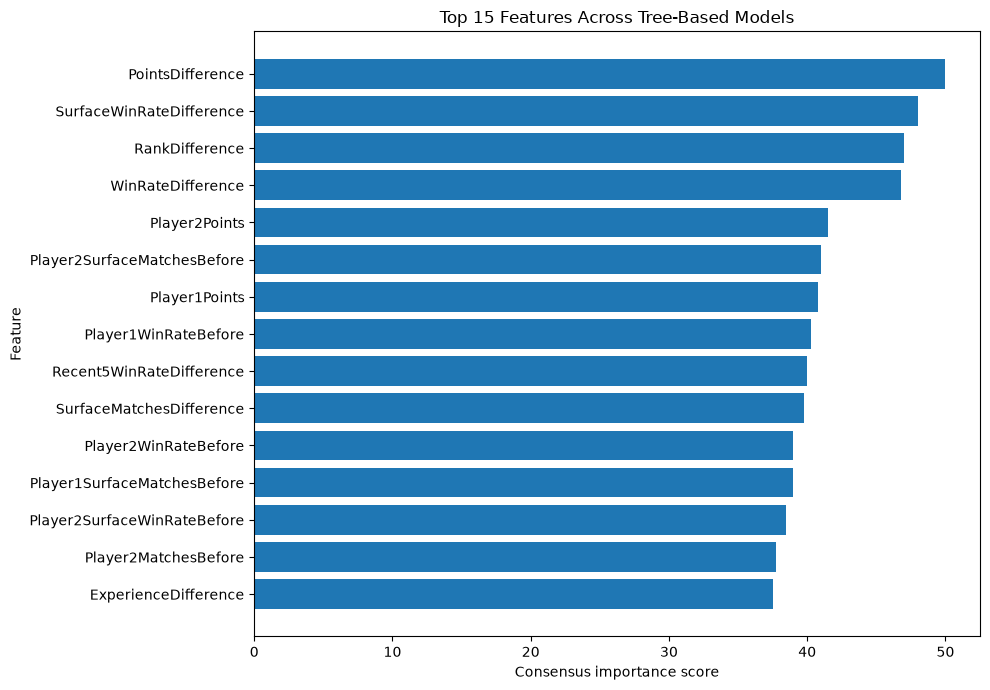

In [20]:
#Consensus score instead of rank
number_of_features = len(
    feature_comparison
)


feature_comparison[
    "ConsensusScore"
] = (
    number_of_features
    + 1
    -
    feature_comparison[
        "AverageRank"
    ]
)

top_15_features = (
    feature_comparison
    .sort_values(
        "ConsensusScore",
        ascending=False
    )
    .head(15)
    .reset_index(
        drop=True
    )
)

plot_data = (
    top_15_features
    .sort_values(
        "ConsensusScore",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    plot_data["Feature"],
    plot_data["ConsensusScore"]
)


plt.xlabel(
    "Consensus importance score"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Features Across Tree-Based Models"
)


plt.tight_layout()

plt.show()

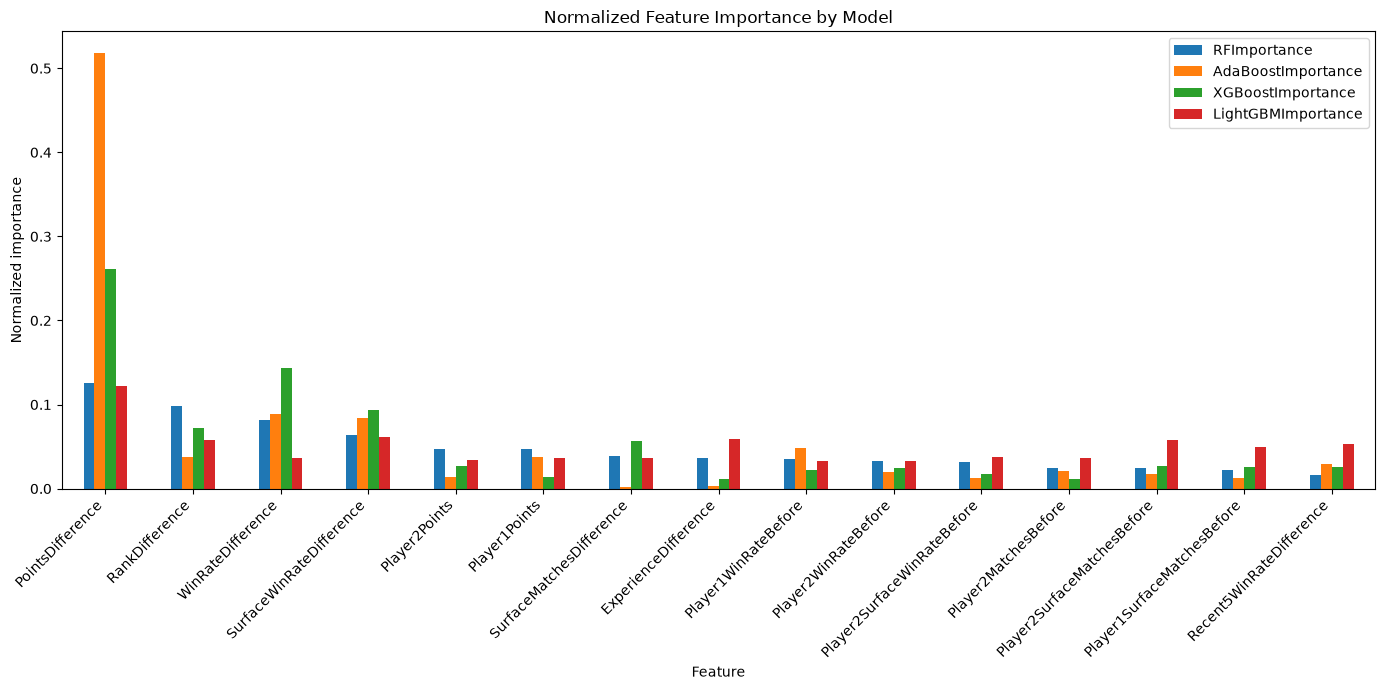

In [21]:
#Compare top features model-by-model
top_feature_names = (
    top_15_features[
        "Feature"
    ]
    .tolist()
)


top_feature_comparison = (
    feature_comparison[
        feature_comparison[
            "Feature"
        ].isin(
            top_feature_names
        )
    ]
    .set_index(
        "Feature"
    )
    [
        [
            "RFImportance",
            "AdaBoostImportance",
            "XGBoostImportance",
            "LightGBMImportance"
        ]
    ]
)

top_feature_comparison.plot(
    kind="bar",
    figsize=(14, 7)
)


plt.ylabel(
    "Normalized importance"
)

plt.xlabel(
    "Feature"
)

plt.title(
    "Normalized Feature Importance by Model"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [23]:
#Measure agreement between models
rank_comparison = (
    feature_comparison[
        [
            "RFRank",
            "AdaBoostRank",
            "XGBoostRank",
            "LightGBMRank"
        ]
    ]
)


rank_correlation = (
    rank_comparison
    .corr(
        method="spearman"
    )
)


rank_correlation

,RFRank,AdaBoostRank,XGBoostRank,LightGBMRank
RFRank,1.000000,0.716819,0.855829,0.886146
AdaBoostRank,0.716819,1.000000,0.739449,0.795130
XGBoostRank,0.855829,0.739449,1.000000,0.875189
LightGBMRank,0.886146,0.795130,0.875189,1.000000


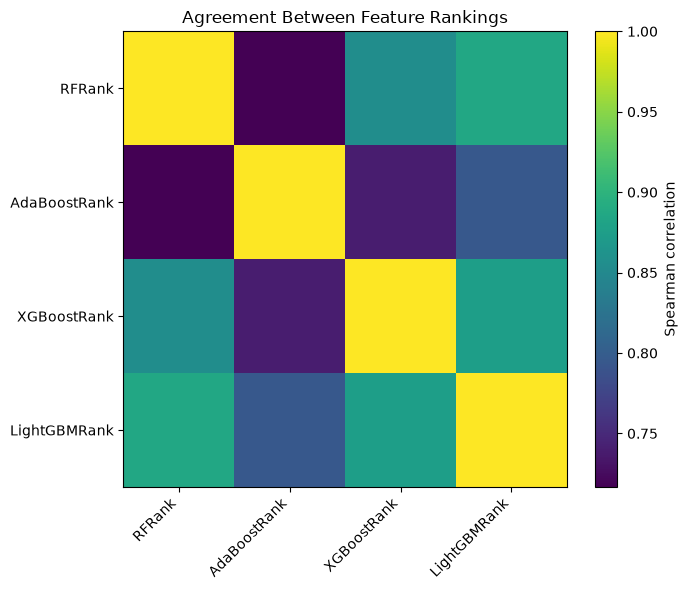

In [24]:
#Plot agreement matrix
plt.figure(
    figsize=(7, 6)
)


plt.imshow(
    rank_correlation,
    aspect="auto"
)


plt.xticks(
    range(
        len(
            rank_correlation.columns
        )
    ),
    rank_correlation.columns,
    rotation=45,
    ha="right"
)


plt.yticks(
    range(
        len(
            rank_correlation.index
        )
    ),
    rank_correlation.index
)


plt.colorbar(
    label="Spearman correlation"
)


plt.title(
    "Agreement Between Feature Rankings"
)


plt.tight_layout()

plt.show()

In [25]:
#Features appearing in every model's top 10
top_10_rf = set(
    feature_comparison
    .nsmallest(
        10,
        "RFRank"
    )[
        "Feature"
    ]
)


top_10_adaboost = set(
    feature_comparison
    .nsmallest(
        10,
        "AdaBoostRank"
    )[
        "Feature"
    ]
)


top_10_xgboost = set(
    feature_comparison
    .nsmallest(
        10,
        "XGBoostRank"
    )[
        "Feature"
    ]
)


top_10_lightgbm = set(
    feature_comparison
    .nsmallest(
        10,
        "LightGBMRank"
    )[
        "Feature"
    ]
)

common_top_10 = (
    top_10_rf
    &
    top_10_adaboost
    &
    top_10_xgboost
    &
    top_10_lightgbm
)


print(
    "Features in the top 10 of all four models:"
)


for feature in sorted(
    common_top_10
):
    print(
        "-",
        feature
    )

Features in the top 10 of all four models:
- PointsDifference
- RankDifference
- SurfaceWinRateDifference
- WinRateDifference


In [26]:
#Count how many models place each feature in top 10
feature_comparison[
    "Top10Count"
] = (
    (
        feature_comparison[
            "RFRank"
        ]
        <= 10
    ).astype(int)
    
    +
    
    (
        feature_comparison[
            "AdaBoostRank"
        ]
        <= 10
    ).astype(int)
    
    +
    
    (
        feature_comparison[
            "XGBoostRank"
        ]
        <= 10
    ).astype(int)
    
    +
    
    (
        feature_comparison[
            "LightGBMRank"
        ]
        <= 10
    ).astype(int)
)

feature_comparison[
    [
        "Feature",
        "Top10Count",
        "AverageRank"
    ]
].sort_values(
    [
        "Top10Count",
        "AverageRank"
    ],
    ascending=[
        False,
        True
    ]
).head(20)

,Feature,Top10Count,AverageRank
0,PointsDifference,4,1.00
3,SurfaceWinRateDifference,4,3.00
1,RankDifference,4,4.00
2,WinRateDifference,4,4.25
15,Player2SurfaceMatchesBefore,3,10.00
8,SurfaceMatchesDifference,3,11.25
4,Player2Points,2,9.50
5,Player1Points,2,10.25
19,Recent5WinRateDifference,2,11.00
17,Player1SurfaceMatchesBefore,2,12.00


In [27]:
#Add a stability measure
feature_comparison[
    "RankStd"
] = (
    feature_comparison[
        rank_columns
    ]
    .std(
        axis=1
    )
)

feature_comparison[
    [
        "Feature",
        "AverageRank",
        "RankStd",
        "Top10Count"
    ]
].sort_values(
    [
        "AverageRank",
        "RankStd"
    ]
).head(15)

,Feature,AverageRank,RankStd,Top10Count
0,PointsDifference,1.00,0.000000,4
3,SurfaceWinRateDifference,3.00,0.816497,4
1,RankDifference,4.00,1.632993,4
2,WinRateDifference,4.25,3.862210,4
4,Player2Points,9.50,3.872983,2
15,Player2SurfaceMatchesBefore,10.00,4.546061,3
5,Player1Points,10.25,5.737305,2
10,Player1WinRateBefore,10.75,4.787136,1
19,Recent5WinRateDifference,11.00,6.377042,2
8,SurfaceMatchesDifference,11.25,6.849574,3


In [28]:
#Create final native-importance comparison table
native_importance_summary = (
    feature_comparison[
        [
            "Feature",
            "RFImportance",
            "AdaBoostImportance",
            "XGBoostImportance",
            "LightGBMImportance",
            "RFRank",
            "AdaBoostRank",
            "XGBoostRank",
            "LightGBMRank",
            "AverageRank",
            "RankStd",
            "Top10Count",
            "ConsensusScore"
        ]
    ]
    .sort_values(
        "AverageRank"
    )
    .reset_index(
        drop=True
    )
)

native_importance_summary.head(15)

,Feature,RFImportance,AdaBoostImportance,XGBoostImportance,LightGBMImportance,RFRank,AdaBoostRank,XGBoostRank,LightGBMRank,AverageRank,RankStd,Top10Count,ConsensusScore
0,PointsDifference,0.125788,0.518056,0.261584,0.121667,1.0,1.0,1.0,1.0,1.00,0.000000,4,50.00
1,SurfaceWinRateDifference,0.063267,0.084506,0.093345,0.061667,4.0,3.0,3.0,2.0,3.00,0.816497,4,48.00
2,RankDifference,0.097723,0.037455,0.072032,0.058333,2.0,6.0,4.0,4.0,4.00,1.632993,4,47.00
3,WinRateDifference,0.081795,0.088530,0.143982,0.036667,3.0,2.0,2.0,10.0,4.25,3.862210,4,46.75
4,Player2Points,0.047606,0.013468,0.027179,0.034167,5.0,11.0,8.0,14.0,9.50,3.872983,2,41.50
5,Player2SurfaceMatchesBefore,0.024166,0.017197,0.026937,0.057500,16.0,10.0,9.0,5.0,10.00,4.546061,3,41.00
6,Player1Points,0.046803,0.038037,0.013616,0.035833,6.0,5.0,17.0,13.0,10.25,5.737305,2,40.75
7,Player1WinRateBefore,0.035744,0.048445,0.021649,0.032500,11.0,4.0,13.0,15.0,10.75,4.787136,1,40.25
8,Recent5WinRateDifference,0.016751,0.028922,0.025799,0.053333,20.0,7.0,11.0,6.0,11.00,6.377042,2,40.00
9,SurfaceMatchesDifference,0.038916,0.002303,0.056334,0.036667,9.0,21.0,5.0,10.0,11.25,6.849574,3,39.75


In [29]:
#Save the comparison
native_importance_summary.to_csv(
    FEATURE_IMPORTANCE_DIR
    / "feature_importance_comparison.csv",
    index=False
)


print(
    "Native feature-importance comparison saved."
)

Native feature-importance comparison saved.


## Interpretation of Native Feature Importance

The tree-based models show both agreement and differences in the features they
consider most relevant.

Features that consistently appear near the top across several models are more
likely to represent robust predictive signals rather than model-specific
effects.

Particular attention is given to:

- features with a low average rank,
- features appearing in the top 10 of several models,
- features with a low variability in rank across models.

Differences between models are expected because each algorithm constructs and
uses decision trees differently and may define native importance using
different criteria.

## Permutation Importance Across All Models

ANN and k-NN do not provide native feature-importance measures.

To compare feature relevance across all six models, permutation importance is
calculated on the 2023 validation set.

For each original input feature:

1. the feature values are randomly shuffled,
2. the validation data are transformed using the preprocessing fitted on the
   training data,
3. predictions are recomputed,
4. the decrease in ROC-AUC is measured.

A larger decrease in ROC-AUC indicates that the model relied more strongly on
that feature.

Permutation is performed before one-hot encoding so that categorical
variables such as Surface and Round remain complete features.

The 2024–2025 final test set is not used.

In [30]:
#Paths
PROCESSED_DATA_DIR = Path(
    "../data/processed"
)

MODELS_DIR = Path(
    "../models"
)

PERMUTATION_FILE = (
    FEATURE_IMPORTANCE_DIR
    / "permutation_feature_importance.csv"
)

In [32]:
#Load the 2023 validation data
matches = pd.read_csv(
    PROCESSED_DATA_DIR
    / "feature_split_matches.csv",
    parse_dates=["Date"]
)


validation_data = (
    matches.loc[
        matches["DataSplit"]
        ==
        "Validation"
    ]
    .copy()
)


y_validation = (
    validation_data[
        "Player1Won"
    ]
    .to_numpy()
)


print(
    "Validation matches:",
    len(validation_data)
)

print(
    "Validation period:",
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

assert set(
    validation_data[
        "Date"
    ].dt.year.unique()
) == {2023}


print(
    "Validation set check passed."
)

Validation matches: 2607
Validation period: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Validation set check passed.


In [33]:
#Load saved preprocessing
validation_preprocessing = (
    joblib.load(
        MODELS_DIR
        / "ann_preprocessing.joblib"
    )
)


numeric_medians = (
    validation_preprocessing[
        "numeric_medians"
    ]
)

categorical_modes = (
    validation_preprocessing[
        "categorical_modes"
    ]
)

one_hot_encoder = (
    validation_preprocessing[
        "one_hot_encoder"
    ]
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)


print(
    "Validation matrix:",
    X_validation.shape
)

Validation matrix: (2607, 50)


In [34]:
#Load all six saved models and the two scalers
ann_model = (
    tf.keras.models.load_model(
        MODELS_DIR
        / "best_ann_validation.keras"
    )
)


rf_model = joblib.load(
    MODELS_DIR
    / "best_rf_validation.joblib"
)


knn_model = joblib.load(
    MODELS_DIR
    / "best_knn_validation.joblib"
)


adaboost_model = joblib.load(
    MODELS_DIR
    / "best_adaboost_validation.joblib"
)


xgboost_model = joblib.load(
    MODELS_DIR
    / "best_xgboost_validation.joblib"
)


lightgbm_model = joblib.load(
    MODELS_DIR
    / "best_lightgbm_validation.joblib"
)

ann_scaler = joblib.load(
    MODELS_DIR
    / "ann_scaler.joblib"
)


knn_scaler = joblib.load(
    MODELS_DIR
    / "best_knn_scaler.joblib"
)

In [35]:
#Put models into one dictionary
models = {
    "ANN":
        ann_model,

    "Random Forest":
        rf_model,

    "k-NN":
        knn_model,

    "AdaBoost":
        adaboost_model,

    "XGBoost":
        xgboost_model,

    "LightGBM":
        lightgbm_model
}

In [36]:
#Common prediction function
def predict_probabilities(
    model_name,
    model,
    raw_data
):
    
    X = transform_data(
        raw_data,
        numeric_medians,
        categorical_modes,
        one_hot_encoder
    )
    
    
    if model_name == "ANN":
        
        X = X.copy()
        
        X[numeric_features] = (
            ann_scaler.transform(
                X[numeric_features]
            )
        )
        
        probabilities = (
            model.predict(
                X.to_numpy(
                    dtype=np.float32
                ),
                verbose=0
            )
            .reshape(-1)
        )
    
    
    elif model_name == "k-NN":
        
        X = X.copy()
        
        X[numeric_features] = (
            knn_scaler.transform(
                X[numeric_features]
            )
        )
        
        probabilities = (
            model.predict_proba(
                X
            )[:, 1]
        )
    
    
    else:
        
        probabilities = (
            model.predict_proba(
                X
            )[:, 1]
        )
    
    
    return probabilities

In [37]:
#Verify loaded models reproduce sensible validation results
baseline_auc = {}


for (
    model_name,
    model
) in models.items():
    
    probabilities = (
        predict_probabilities(
            model_name,
            model,
            validation_data
        )
    )
    
    auc = roc_auc_score(
        y_validation,
        probabilities
    )
    
    baseline_auc[
        model_name
    ] = auc
    
    print(
        model_name,
        "- ROC-AUC:",
        round(
            auc,
            4
        )
    )

ANN - ROC-AUC: 0.7021
Random Forest - ROC-AUC: 0.7038
k-NN - ROC-AUC: 0.7005
AdaBoost - ROC-AUC: 0.6987
XGBoost - ROC-AUC: 0.7032
LightGBM - ROC-AUC: 0.7016


In [38]:
#Define permutation importance function
def calculate_permutation_importance(
    model_name,
    model,
    validation_data,
    y_true,
    n_repeats=3,
    random_state=42
):
    
    baseline_probabilities = (
        predict_probabilities(
            model_name,
            model,
            validation_data
        )
    )
    
    
    baseline_score = (
        roc_auc_score(
            y_true,
            baseline_probabilities
        )
    )
    
    
    original_features = (
        numeric_features
        +
        categorical_features
    )
    
    
    results = []
    
    
    for feature in original_features:
        
        decreases = []
        
        
        for repeat in range(
            n_repeats
        ):
            
            rng = np.random.default_rng(
                random_state
                +
                repeat
            )
            
            
            permuted_data = (
                validation_data.copy()
            )
            
            
            permuted_data[
                feature
            ] = rng.permutation(
                permuted_data[
                    feature
                ].to_numpy()
            )
            
            
            permuted_probabilities = (
                predict_probabilities(
                    model_name,
                    model,
                    permuted_data
                )
            )
            
            
            permuted_auc = (
                roc_auc_score(
                    y_true,
                    permuted_probabilities
                )
            )
            
            
            decreases.append(
                baseline_score
                -
                permuted_auc
            )
        
        
        results.append(
            {
                "Model":
                    model_name,
                
                "Feature":
                    feature,
                
                "BaselineROCAUC":
                    baseline_score,
                
                "MeanDecreaseROCAUC":
                    np.mean(
                        decreases
                    ),
                
                "StdDecreaseROCAUC":
                    np.std(
                        decreases
                    )
            }
        )
    
    
    return pd.DataFrame(
        results
    )

In [39]:
#Calculate OR load saved permutation importance
if PERMUTATION_FILE.exists():
    
    print(
        "Loading saved permutation importance..."
    )
    
    permutation_importance = (
        pd.read_csv(
            PERMUTATION_FILE
        )
    )

else:
    
    print(
        "Calculating permutation importance..."
    )
    
    
    permutation_results = []
    
    
    for (
        model_name,
        model
    ) in models.items():
        
        print(
            "\nModel:",
            model_name
        )
        
        
        current_importance = (
            calculate_permutation_importance(
                model_name=
                    model_name,
                
                model=
                    model,
                
                validation_data=
                    validation_data,
                
                y_true=
                    y_validation,
                
                n_repeats=3,
                
                random_state=42
            )
        )
        
        
        permutation_results.append(
            current_importance
        )
    
    
    permutation_importance = (
        pd.concat(
            permutation_results,
            ignore_index=True
        )
    )
    
    
    permutation_importance.to_csv(
        PERMUTATION_FILE,
        index=False
    )
    
    
    print(
        "\nPermutation importance saved."
    )

Calculating permutation importance...

Model: ANN

Model: Random Forest

Model: k-NN

Model: AdaBoost

Model: XGBoost

Model: LightGBM

Permutation importance saved.


In [40]:
#Inspect results
permutation_importance.head()

print(
    "Rows:",
    len(
        permutation_importance
    )
)

Rows: 210


In [41]:
#Top 10 for each of all six models
for model_name in models.keys():
    
    print(
        "\n",
        "=" * 60
    )
    
    print(
        model_name
    )
    
    print(
        "=" * 60
    )
    
    
    display(
        permutation_importance.loc[
            permutation_importance[
                "Model"
            ]
            ==
            model_name
        ]
        .sort_values(
            "MeanDecreaseROCAUC",
            ascending=False
        )
        .head(10)
        [
            [
                "Feature",
                "MeanDecreaseROCAUC",
                "StdDecreaseROCAUC"
            ]
        ]
    )


ANN


,Feature,MeanDecreaseROCAUC,StdDecreaseROCAUC
15,SurfaceMatchesDifference,0.048744,0.003567
14,Player2SurfaceMatchesBefore,0.041678,0.001240
6,ExperienceDifference,0.032171,0.001536
18,SurfaceWinRateDifference,0.024297,0.002043
0,Player1Rank,0.021795,0.002548
3,Player2Points,0.018797,0.001558
25,DaysSinceLastMatchDifference,0.009261,0.003584
13,Player1SurfaceMatchesBefore,0.008410,0.002138
8,Player2WinRateBefore,0.008368,0.001192
4,Player1MatchesBefore,0.006588,0.001395



Random Forest


,Feature,MeanDecreaseROCAUC,StdDecreaseROCAUC
64,PointsDifference,0.008298,0.000709
63,RankDifference,0.006838,0.000239
35,Player1Rank,0.003431,0.000444
36,Player2Rank,0.003125,0.000760
53,SurfaceWinRateDifference,0.002317,0.001106
38,Player2Points,0.001414,0.000698
44,WinRateDifference,0.001146,0.001853
60,DaysSinceLastMatchDifference,0.001073,0.000433
59,Player2DaysSinceLastMatch,0.000976,0.000292
41,ExperienceDifference,0.000945,0.000468



k-NN


...

,Feature,MeanDecreaseROCAUC,StdDecreaseROCAUC
134,PointsDifference,0.087812,0.005720
123,SurfaceWinRateDifference,0.005790,0.001550
133,RankDifference,0.005202,0.000525
118,Player1SurfaceMatchesBefore,0.001757,0.000124
119,Player2SurfaceMatchesBefore,0.001696,0.000710
117,Recent5WinRateDifference,0.001573,0.001365
109,Player1MatchesBefore,0.000852,0.000211
130,DaysSinceLastMatchDifference,0.000687,0.000056
110,Player2MatchesBefore,0.000539,0.000306
120,SurfaceMatchesDifference,0.000476,0.000230



XGBoost


,Feature,MeanDecreaseROCAUC,StdDecreaseROCAUC
169,PointsDifference,0.059019,0.003114
168,RankDifference,0.006391,0.000555
158,SurfaceWinRateDifference,0.004615,0.000700
153,Player1SurfaceMatchesBefore,0.002745,0.000790
154,Player2SurfaceMatchesBefore,0.001992,0.000668
165,DaysSinceLastMatchDifference,0.001694,0.000135
152,Recent5WinRateDifference,0.001532,0.001025
145,Player2MatchesBefore,0.001370,0.000182
157,Player2SurfaceWinRateBefore,0.000796,0.000407
143,Player2Points,0.000714,0.000266



LightGBM


,Feature,MeanDecreaseROCAUC,StdDecreaseROCAUC
204,PointsDifference,0.046114,0.001954
203,RankDifference,0.005461,0.001270
193,SurfaceWinRateDifference,0.005364,0.001570
189,Player2SurfaceMatchesBefore,0.005316,0.001509
181,ExperienceDifference,0.005021,0.001109
188,Player1SurfaceMatchesBefore,0.004776,0.001802
200,DaysSinceLastMatchDifference,0.003782,0.000461
190,SurfaceMatchesDifference,0.002073,0.000592
187,Recent5WinRateDifference,0.001484,0.000804
191,Player1SurfaceWinRateBefore,0.001307,0.000227


In [42]:
#Convert to comparison table
permutation_comparison = (
    permutation_importance
    .pivot(
        index="Feature",
        columns="Model",
        values="MeanDecreaseROCAUC"
    )
    .reset_index()
)


permutation_comparison.head()

Model,Feature,ANN,AdaBoost,LightGBM,Random Forest,XGBoost,k-NN
0,Best of,0.001638,0.000000,0.000072,0.000199,0.000040,-0.000094
1,Court,0.002643,0.000000,-0.000027,0.000030,0.000000,0.000212
2,DaysSinceLastMatchDifference,0.009261,0.000687,0.003782,0.001073,0.001694,0.002149
3,DifferenceH2HWinRateBefore,0.000943,-0.000051,-0.000029,0.000008,0.000000,-0.001362
4,ExperienceDifference,0.032171,0.000245,0.005021,0.000945,0.000344,0.001578


In [43]:
#Rank permutation importance within each model
model_columns = [
    "ANN",
    "Random Forest",
    "k-NN",
    "AdaBoost",
    "XGBoost",
    "LightGBM"
]


for model_name in model_columns:
    
    permutation_comparison[
        model_name
        +
        "Rank"
    ] = (
        permutation_comparison[
            model_name
        ]
        .rank(
            ascending=False,
            method="min"
        )
    )

In [44]:
#All-six consensus ranking
permutation_rank_columns = [
    model_name
    +
    "Rank"
    for model_name
    in model_columns
]


permutation_comparison[
    "AverageRank"
] = (
    permutation_comparison[
        permutation_rank_columns
    ]
    .mean(
        axis=1
    )
)

permutation_comparison[
    "AverageImportance"
] = (
    permutation_comparison[
        model_columns
    ]
    .mean(
        axis=1
    )
)

all_model_consensus = (
    permutation_comparison
    .sort_values(
        "AverageRank"
    )
    .reset_index(
        drop=True
    )
)


all_model_consensus[
    [
        "Feature",
        "AverageRank",
        "AverageImportance"
    ]
].head(15)

Model,Feature,AverageRank,AverageImportance
0,PointsDifference,3.833333,0.035012
1,RankDifference,4.333333,0.006194
2,SurfaceWinRateDifference,6.333333,0.007165
3,DaysSinceLastMatchDifference,7.500000,0.003107
4,Player2Points,9.000000,0.004240
5,ExperienceDifference,9.833333,0.006717
6,Player1MatchesBefore,11.166667,0.001882
7,Player1SurfaceMatchesBefore,12.000000,0.002982
8,Player2SurfaceMatchesBefore,12.500000,0.008230
9,Player1Rank,12.833333,0.005067


In [45]:
#Count top-10 appearances across all six
all_model_consensus[
    "Top10Count"
] = 0


for rank_column in (
    permutation_rank_columns
):
    
    all_model_consensus[
        "Top10Count"
    ] += (
        all_model_consensus[
            rank_column
        ]
        <= 10
    ).astype(int)

all_model_consensus[
    [
        "Feature",
        "Top10Count",
        "AverageRank",
        "AverageImportance"
    ]
].sort_values(
    [
        "Top10Count",
        "AverageRank"
    ],
    ascending=[
        False,
        True
    ]
).head(20)

Model,Feature,Top10Count,AverageRank,AverageImportance
3,DaysSinceLastMatchDifference,6,7.500000,0.003107
0,PointsDifference,5,3.833333,0.035012
1,RankDifference,5,4.333333,0.006194
2,SurfaceWinRateDifference,5,6.333333,0.007165
4,Player2Points,4,9.000000,0.004240
7,Player1SurfaceMatchesBefore,4,12.000000,0.002982
8,Player2SurfaceMatchesBefore,4,12.500000,0.008230
5,ExperienceDifference,3,9.833333,0.006717
6,Player1MatchesBefore,3,11.166667,0.001882
9,Player1Rank,3,12.833333,0.005067


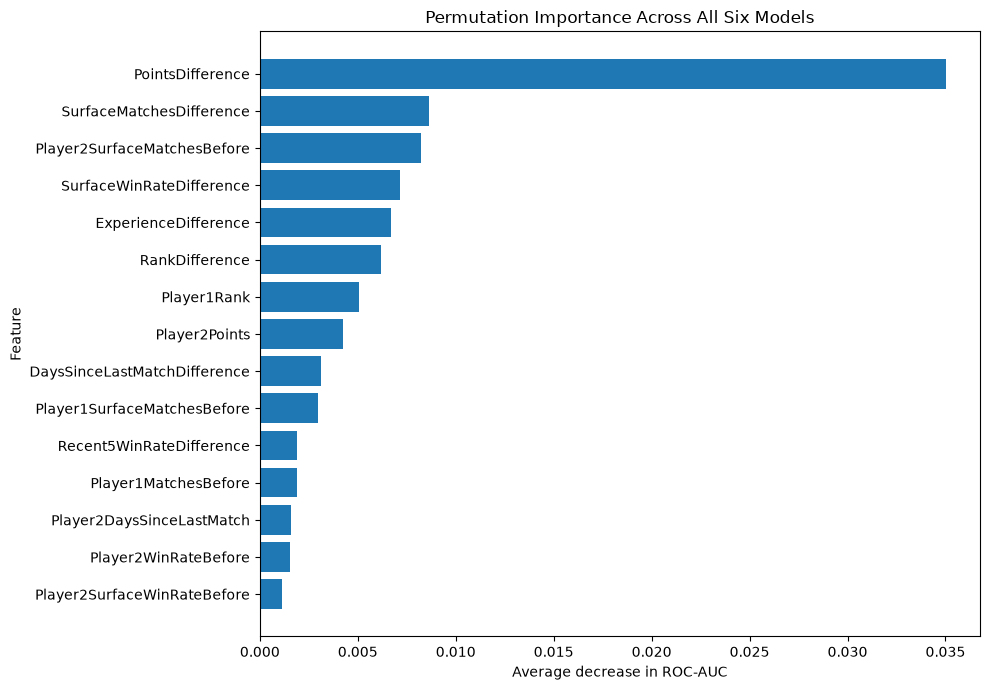

In [46]:
#Plot top 15 across all six models
top_15_all_models = (
    all_model_consensus
    .head(15)
    .copy()
)


plot_data = (
    top_15_all_models
    .sort_values(
        "AverageImportance",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)


plt.barh(
    plot_data["Feature"],
    plot_data[
        "AverageImportance"
    ]
)


plt.xlabel(
    "Average decrease in ROC-AUC"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Permutation Importance Across All Six Models"
)


plt.tight_layout()

plt.show()

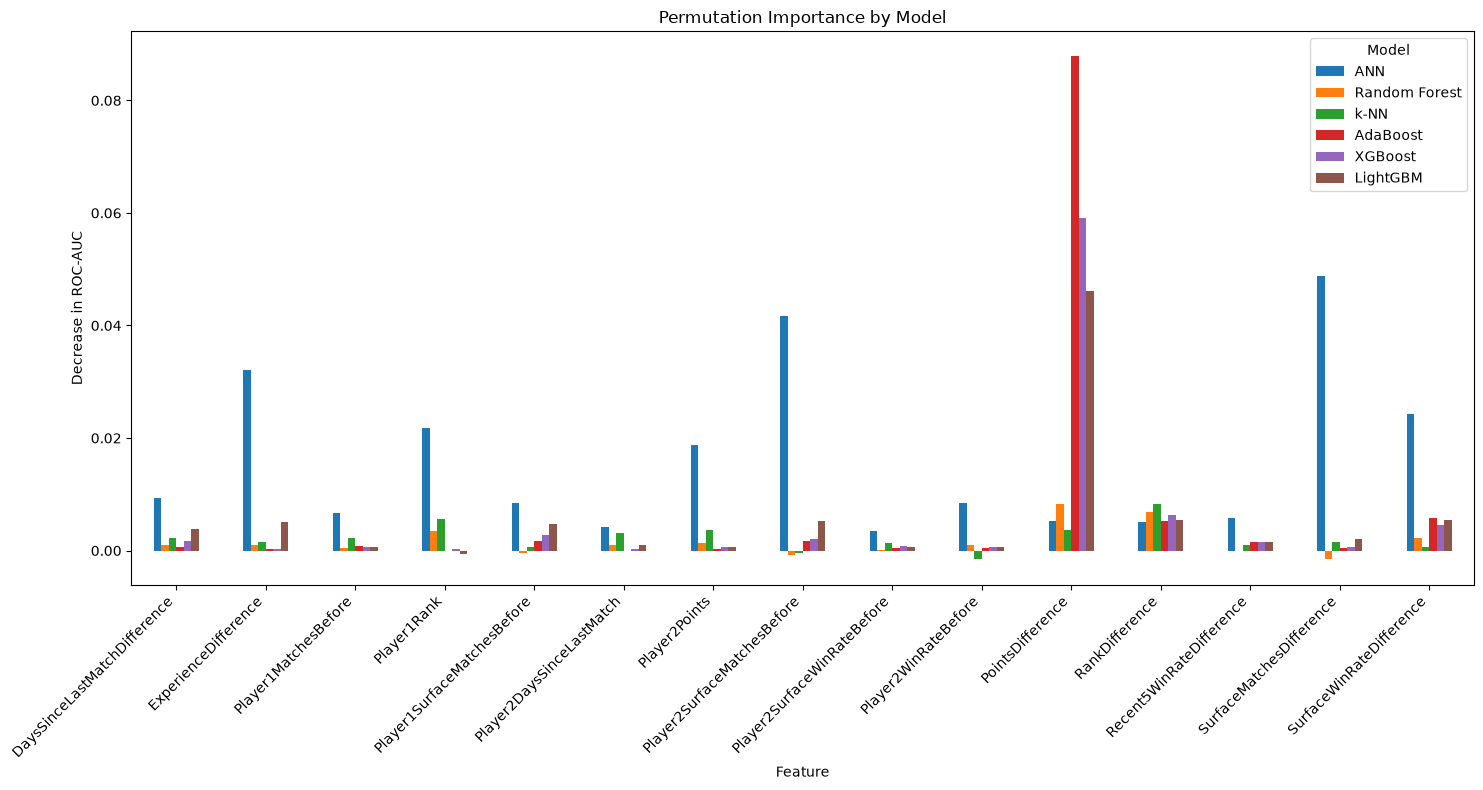

In [47]:
#Compare individual models visually
top_feature_names = (
    top_15_all_models[
        "Feature"
    ]
    .tolist()
)


plot_comparison = (
    permutation_comparison.loc[
        permutation_comparison[
            "Feature"
        ].isin(
            top_feature_names
        )
    ]
    .set_index(
        "Feature"
    )[
        model_columns
    ]
)

plot_comparison.plot(
    kind="bar",
    figsize=(15, 8)
)


plt.ylabel(
    "Decrease in ROC-AUC"
)

plt.xlabel(
    "Feature"
)

plt.title(
    "Permutation Importance by Model"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()

plt.show()

In [48]:
#Save all-six comparison
all_model_consensus.to_csv(
    FEATURE_IMPORTANCE_DIR
    / "permutation_importance_comparison.csv",
    index=False
)


print(
    "Permutation importance comparison saved."
)

Permutation importance comparison saved.


## Overall Feature Importance Findings

Two complementary approaches were used to study feature relevance.

First, the native feature-importance measures of Random Forest, AdaBoost,
XGBoost and LightGBM were compared. Because these models define importance
differently, the analysis focused mainly on normalized importance and feature
rankings.

Second, permutation importance was calculated on the 2023 validation set for
all six models, including ANN and k-NN. This provides a common definition of
importance across different model families.

Features that rank highly under both analyses and across several models can
be considered the most robust predictive variables.

Features with substantial differences between models may instead represent
model-specific behaviour or interactions.

The feature-importance analysis is performed entirely before the final
2024–2025 evaluation, preserving the final test set as an untouched estimate
of future predictive performance.

In [49]:
#Final notebook summary
print(
    "=" * 70
)

print(
    "FEATURE IMPORTANCE ANALYSIS COMPLETE"
)

print(
    "=" * 70
)


print(
    "\nNative importance models:"
)

print(
    "Random Forest, AdaBoost, XGBoost, LightGBM"
)


print(
    "\nPermutation importance models:"
)

print(
    "ANN, Random Forest, k-NN, AdaBoost, XGBoost, LightGBM"
)


print(
    "\nNumber of original features:",
    len(
        numeric_features
        +
        categorical_features
    )
)


print(
    "\nTop 10 consensus features:"
)


display(
    all_model_consensus[
        [
            "Feature",
            "AverageRank",
            "Top10Count",
            "AverageImportance"
        ]
    ]
    .head(10)
)

FEATURE IMPORTANCE ANALYSIS COMPLETE

Native importance models:
Random Forest, AdaBoost, XGBoost, LightGBM

Permutation importance models:
ANN, Random Forest, k-NN, AdaBoost, XGBoost, LightGBM

Number of original features: 35

Top 10 consensus features:


Model,Feature,AverageRank,Top10Count,AverageImportance
0,PointsDifference,3.833333,5,0.035012
1,RankDifference,4.333333,5,0.006194
2,SurfaceWinRateDifference,6.333333,5,0.007165
3,DaysSinceLastMatchDifference,7.500000,6,0.003107
4,Player2Points,9.000000,4,0.004240
5,ExperienceDifference,9.833333,3,0.006717
6,Player1MatchesBefore,11.166667,3,0.001882
7,Player1SurfaceMatchesBefore,12.000000,4,0.002982
8,Player2SurfaceMatchesBefore,12.500000,4,0.008230
9,Player1Rank,12.833333,3,0.005067
